In [1]:
import torch # главная библиотека, в торче лежит всё
from torch.utils.data import Dataset, DataLoader # Dataset - хранилище данных, DataLoader - загрузчик, через который мы будем получать данные
from torch.optim import AdamW # наш оптимизатор, он смотрит на ошибку и меняет веса, чтобы сеть лучше работала
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns

import torch.nn as nn
from torch.amp import GradScaler
from torch.utils.data import random_split
from sklearn.preprocessing import TargetEncoder

In [2]:
data = pd.read_csv("diamonds.csv")
data

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [3]:
result = data.groupby('cut').agg({'price' : 'mean'})
result

,price
cut,
Fair,4358.757764
Good,3928.864452
Ideal,3457.541970
Premium,4584.257704
Very Good,3981.759891


In [4]:
data['carat'].max()

np.float64(5.01)

In [5]:
data = data.drop(['cut','color','clarity','Unnamed: 0'],axis = 1)
data['carat_2'] = data['carat']*data['carat']
data['volume'] = data['x']*data['y']*data['z']
data['poh'] = np.log(data['carat']+data['x'])
data


,carat,depth,table,price,x,y,z,carat_2,volume,poh
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0.0529,38.202030,1.430311
1,0.21,59.8,61.0,326,3.89,3.84,2.31,0.0441,34.505856,1.410987
2,0.23,56.9,65.0,327,4.05,4.07,2.31,0.0529,38.076885,1.453953
3,0.29,62.4,58.0,334,4.20,4.23,2.63,0.0841,46.724580,1.501853
4,0.31,63.3,58.0,335,4.34,4.35,2.75,0.0961,51.917250,1.536867
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50,0.5184,115.920000,1.867176
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61,0.5184,118.110175,1.857859
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56,0.4900,114.449728,1.850028
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74,0.7396,140.766120,1.947338


In [6]:
# sns.pairplot( # матрица диаграмм рассеяния из Seaborn
# data = data, # данные
# hue = 'carat', # имя столбца в данных для раскраски меток
# corner = True # матрица симметрична, не будем выводить лишние графики
# ).fig.suptitle( # настройки заголовка
# 'Зависимости для признаков', # заголовок
# y = 1.08 # расположение
# )

In [7]:
class DiamondDataset(Dataset):
    def __init__(self, x, y):
        super().__init__()
        
        # Обработка x (признаки)
        if isinstance(x, pd.DataFrame):
            self.x = x.reset_index(drop=True).values.astype(np.float32)
        elif isinstance(x, np.ndarray):
            self.x = x.astype(np.float32)
        elif isinstance(x, torch.Tensor):
            self.x = x.numpy().astype(np.float32)
        else:
            self.x = np.array(x).astype(np.float32)
        
        # Обработка y (целевая переменная)
        if isinstance(y, (pd.Series, pd.DataFrame)):
            self.y = y.reset_index(drop=True).values.astype(np.float32)
        elif isinstance(y, np.ndarray):
            self.y = y.astype(np.float32)
        elif isinstance(y, torch.Tensor):
            self.y = y.numpy().astype(np.float32)
        else:
            self.y = np.array(y).astype(np.float32)
        
        # Убеждаемся, что y правильной формы
        if len(self.y.shape) == 1:
            self.y = self.y.reshape(-1, 1)
    
    def __getitem__(self, index): # data[0]
        x = self.x[index]
        y = self.y[index]
        
        x = torch.from_numpy(x).float()
        y = torch.from_numpy(np.array([y])).float()
        
        return x, y
    
    def __len__(self):
        return len(self.x)

In [8]:
class Trainer:
    def __init__(self, model, device, optimizer, train_loader, val_loader):
        if isinstance(device, str):
            self.device = torch.device(device)
        else:
            self.device = device

        #self.device = device
        self.model = model.to(device)

        self.optimizer = optimizer 
        self.train_loader = train_loader
        self.val_loader = val_loader

        self.use_amp = (self.device.type == "cuda")

        if self.use_amp and torch.cuda.is_bf16_supported():
            self.dtype = torch.bfloat16
        else:
            self.dtype = torch.float16

        # GradScaler is needed only for fp16
        self.scaler = GradScaler(
            enabled=(self.use_amp and self.dtype == torch.float16)
        )
        
        self.criterion = nn.SmoothL1Loss(beta=1.0)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        device_type = self.device.type

        for x, target in self.train_loader :
            x = x.to(self.device)
            target = target.to(self.device)

            self.optimizer.zero_grad(set_to_none = True)

            with torch.autocast(
                device_type = device_type,
                dtype = self.dtype,
                enabled = self.use_amp
            ):
                outputs = self.model(x)
                loss = self.criterion(outputs, target)

            self.scaler.scale(loss).backward()

            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm = 1.0)

            self.scaler.step(self.optimizer)
            self.scaler.update()

            total_loss += loss.item()

        return total_loss / len(self.train_loader)
    
    @torch.no_grad()
    def eval_epoch(self):
        self.model.eval()
        total_loss = 0.0

        device_type = self.device.type

        for x, y in self.val_loader:
            x = x.to(self.device)
            y = y.to(self.device)

            with torch.autocast(
                device_type=device_type,
                dtype=self.dtype,
                enabled=self.use_amp,
            ):
                outputs = self.model(x)
                loss = self.criterion(outputs, y)

            total_loss += loss.item()

        return total_loss / len(self.val_loader)





    

In [9]:
class myModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_1 = nn.Linear(9,16)
        self.linear_2 = nn.Linear(16,32)
        self.linear_3 = nn.Linear(32,16)
        self.linear_4 = nn.Linear(16,64)
        self.linear_5 = nn.Linear(64,1)

        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.linear_1(x)
        out = self.relu(out)
        out = self.linear_2(out)
        out = self.relu(out)
        out = self.linear_3(out)
        out = self.relu(out)
        out = self.linear_4(out)
        out = self.relu(out)
        out = self.linear_5(out)

        return out.unsqueeze(dim = -1)




In [10]:
#DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
DEVICE = torch.device("cpu") 
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")
    
get_device()

device(type='cpu')

In [11]:
y = data['price']
x = data.drop('price', axis=1)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)


scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

train_ds = DiamondDataset(x_train_scaled, y_train)
test_ds = DiamondDataset(x_test_scaled, y_test)

train_loader = DataLoader(train_ds,batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds,batch_size=128)

In [12]:
model = myModel().to(DEVICE)
optimizer = AdamW(model.parameters(), lr=0.001)
#criterion = torch.nn.MSELoss()

trainer = Trainer(model, DEVICE, optimizer, train_loader, test_loader)

In [13]:
# Проверка устройства модели
print(f"🔍 Model device: {next(trainer.model.parameters()).device}")

# Проверка устройства данных в loader
x_sample, _ = next(iter(train_loader))
print(f"🔍 Data device: {x_sample.device}")

# Проверка, используется ли CUDA
print(f"🔍 CUDA available: {torch.cuda.is_available()}")
print(f"🔍 Current device: {trainer.device}")

🔍 Model device: cpu
🔍 Data device: cpu
🔍 CUDA available: False
🔍 Current device: cpu


In [14]:
x_sample, y_sample = train_ds[0]
print(f"Первый пример:")
print(f"Признаки (x): {x_sample}")
print(f"Цена (y): {y_sample}")

Первый пример:
Признаки (x): tensor([-0.5035, -0.5217, -0.2058, -0.3415, -0.3989, -0.4240, -0.5200, -0.4901,
        -0.2989])
Цена (y): tensor([[2066.]])


In [15]:
epoch = 100

for i in range(epoch):
    train_loss = trainer.train_epoch()
    val_loss = trainer.eval_epoch()
    print(f"Ephose: {i}, Loss: {train_loss}  val loss : {val_loss}")

Ephose: 0, Loss: 2965.999838096217  val loss : 1039.4723482353743
Ephose: 1, Loss: 889.7293041028474  val loss : 832.5996235692223
Ephose: 2, Loss: 823.5675455193771  val loss : 808.5568961210029
Ephose: 3, Loss: 810.027723774157  val loss : 796.6768373001454
Ephose: 4, Loss: 804.6272295500103  val loss : 794.3202614007994
Ephose: 5, Loss: 802.1987439607319  val loss : 789.396150810774
Ephose: 6, Loss: 801.5163553338302  val loss : 788.9817774573038
Ephose: 7, Loss: 799.9969353123715  val loss : 787.6942536110101
Ephose: 8, Loss: 798.6730444657176  val loss : 785.0289661496184
Ephose: 9, Loss: 796.7606641267475  val loss : 784.9026404092479
Ephose: 10, Loss: 798.1217233758224  val loss : 787.0572041356286


KeyboardInterrupt: 

МЕТРИКИ РЕГРЕССИИ
MAE (Mean Absolute Error):   $780.07
MSE (Mean Squared Error):    $2041855.62
RMSE (Root Mean Squared Error): $1428.94
R² Score:                    0.8735

Средние значения:
  Истинная цена (среднее):   $3895.79
  Предсказанная цена (среднее): $3779.34


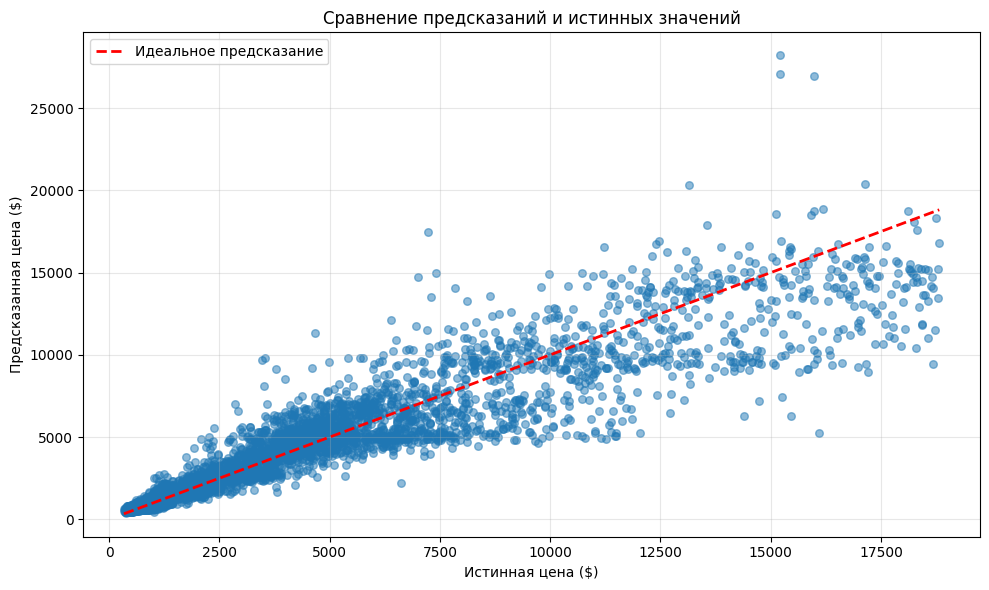

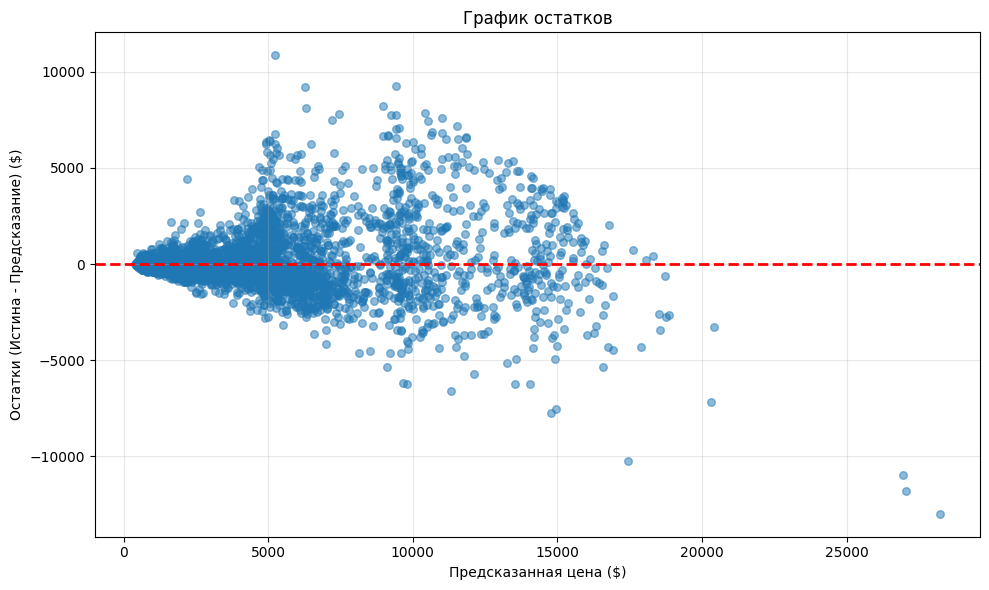

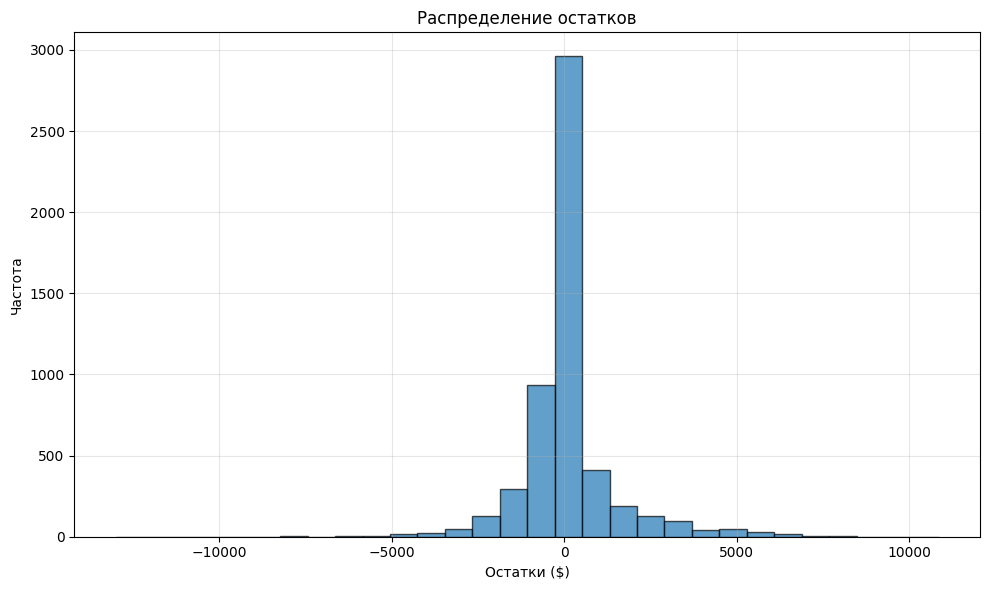


ПРИМЕРЫ ПРЕДСКАЗАНИЙ (первые 15 примеров)
Пример  1: Истина=$559.00, Предсказание=$486.44, Ошибка=$72.56 (13.0%)
Пример  2: Истина=$2201.00, Предсказание=$1941.64, Ошибка=$259.36 (11.8%)
Пример  3: Истина=$1238.00, Предсказание=$962.21, Ошибка=$275.79 (22.3%)
Пример  4: Истина=$1304.00, Предсказание=$1130.17, Ошибка=$173.83 (13.3%)
Пример  5: Истина=$6901.00, Предсказание=$10314.09, Ошибка=$3413.09 (49.5%)
Пример  6: Истина=$3011.00, Предсказание=$4259.88, Ошибка=$1248.88 (41.5%)
Пример  7: Истина=$1765.00, Предсказание=$1668.85, Ошибка=$96.15 (5.4%)
Пример  8: Истина=$1679.00, Предсказание=$1657.58, Ошибка=$21.42 (1.3%)
Пример  9: Истина=$2102.00, Предсказание=$2106.36, Ошибка=$4.36 (0.2%)
Пример 10: Истина=$4789.00, Предсказание=$6382.75, Ошибка=$1593.75 (33.3%)
Пример 11: Истина=$855.00, Предсказание=$896.65, Ошибка=$41.65 (4.9%)
Пример 12: Истина=$13134.00, Предсказание=$12324.10, Ошибка=$809.90 (6.2%)
Пример 13: Истина=$1367.00, Предсказание=$1811.30, Ошибка=$444.30 (32.5%)
Приме

In [ ]:
# Переводим модель в режим оценки
model.eval()

# Списки для сбора всех предсказаний и истинных значений
all_predictions = []
all_targets = []

# Отключаем градиенты для экономии памяти и ускорения
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        # Получаем предсказания модели
        batch_x = batch_x.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        outputs = model(batch_x)  # выходы регрессионной модели
        
        # Сохраняем результаты
        all_predictions.extend(outputs.cpu().numpy().flatten())
        all_targets.extend(batch_y.cpu().numpy().flatten())

# Конвертируем в numpy массивы
all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

print("="*60)
print("МЕТРИКИ РЕГРЕССИИ")
print("="*60)

# Вычисляем ошибки
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(all_targets, all_predictions)
mse = mean_squared_error(all_targets, all_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(all_targets, all_predictions)

print(f"MAE (Mean Absolute Error):   ${mae:.2f}")
print(f"MSE (Mean Squared Error):    ${mse:.2f}")
print(f"RMSE (Root Mean Squared Error): ${rmse:.2f}")
print(f"R² Score:                    {r2:.4f}")

# Средние значения
print(f"\nСредние значения:")
print(f"  Истинная цена (среднее):   ${all_targets.mean():.2f}")
print(f"  Предсказанная цена (среднее): ${all_predictions.mean():.2f}")

# 1. График: Истинные vs Предсказанные значения
plt.figure(figsize=(10, 6))
plt.scatter(all_targets, all_predictions, alpha=0.5, s=30)
plt.plot([all_targets.min(), all_targets.max()], 
         [all_targets.min(), all_targets.max()], 
         'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Истинная цена ($)')
plt.ylabel('Предсказанная цена ($)')
plt.title('Сравнение предсказаний и истинных значений')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. График остатков (Residuals)
residuals = all_targets - all_predictions
plt.figure(figsize=(10, 6))
plt.scatter(all_predictions, residuals, alpha=0.5, s=30)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Предсказанная цена ($)')
plt.ylabel('Остатки (Истина - Предсказание) ($)')
plt.title('График остатков')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Распределение остатков
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Остатки ($)')
plt.ylabel('Частота')
plt.title('Распределение остатков')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Примеры предсказаний на тестовой выборке
print("\n" + "="*60)
print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ (первые 15 примеров)")
print("="*60)

model.eval()
with torch.no_grad():
    for i in range(min(15, len(test_ds))):
        x_sample, y_sample = test_ds[i]
        x_sample = x_sample.to(DEVICE)
        y_sample = y_sample.to(DEVICE)
        
        # Добавляем batch dimension
        x_sample = x_sample.unsqueeze(0)
        
        # Предсказание
        output = model(x_sample).item()
        true_value = y_sample.item()
        error = abs(true_value - output)
        error_percent = (error / true_value) * 100
        
        print(f"Пример {i+1:2d}: Истина=${true_value:.2f}, "
              f"Предсказание=${output:.2f}, "
              f"Ошибка=${error:.2f} ({error_percent:.1f}%)")

# 5. Дополнительная статистика ошибок
print("\n" + "="*60)
print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА ОШИБОК")
print("="*60)

errors = np.abs(all_targets - all_predictions)
percent_errors = (errors / all_targets) * 100

print(f"\nАбсолютные ошибки:")
print(f"  Минимум:     ${errors.min():.2f}")
print(f"  Максимум:    ${errors.max():.2f}")
print(f"  Среднее:     ${errors.mean():.2f}")
print(f"  Медиана:     ${np.median(errors):.2f}")
print(f"  Станд. откл: ${errors.std():.2f}")

print(f"\nПроцентные ошибки:")
print(f"  Минимум:     {percent_errors.min():.2f}%")
print(f"  Максимум:    {percent_errors.max():.2f}%")
print(f"  Среднее:     {percent_errors.mean():.2f}%")
print(f"  Медиана:     {np.median(percent_errors):.2f}%")

# Процент предсказаний с ошибкой менее 10%
within_10_percent = np.sum(percent_errors < 10) / len(percent_errors) * 100
within_20_percent = np.sum(percent_errors < 20) / len(percent_errors) * 100

print(f"\nПроцент предсказаний:")
print(f"  Ошибка < 10%: {within_10_percent:.2f}%")
print(f"  Ошибка < 20%: {within_20_percent:.2f}%")